In [19]:
# Базовые библиотеки
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import json
import pandas as pd
from collections import OrderedDict

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# Датасеты / трансформации
import torchvision
from torchvision import transforms

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.5.1+cu124
torchvision: 0.20.1+cu124


In [2]:
def set_seed(seed: int = 42) -> None:
    # Фиксируем seed для воспроизводимости (насколько это возможно).
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Более детерминированное поведение (может чуть замедлить).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("cuda_available:", torch.cuda.is_available())

device: cuda
cuda_available: True


In [3]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    # Accuracy для классификации: logits -> argmax -> сравнение с y_true.
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def plot_history(history: dict, title: str = "") -> None:
    # history ожидается вида:
    # {
    #   "train_loss": [...], "val_loss": [...],
    #   "train_acc": [...],  "val_acc": [...]
    # }
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

In [4]:
# Трансформации: ToTensor и Normalize
# FashionMNIST уже в [0,1] после ToTensor, но нормализация помогает обучению.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),  # mean/std для 1 канала
])

# Скачиваем датасет
train_full = torchvision.datasets.EMNIST(
    root="./data", split="balanced", train=True, download=True, transform=transform
)
test_ds = torchvision.datasets.EMNIST(
    root="./data", split="balanced", train=False, download=True, transform=transform
)

class_names = train_full.classes
print("classes:", class_names)
print("class_num:", len(class_names))
print("train size:", len(train_full))
print("test size:", len(test_ds))

classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']
class_num: 47
train size: 112800
test size: 18800


In [5]:
# Размер батча подстроим под наличие GPU
BATCH_SIZE = 256 if device.type == "cuda" else 64

# На Windows в Jupyter иногда бывают проблемы с multiprocessing в DataLoader.
# Поэтому автоматически ставим num_workers=0 на Windows, иначе 2.
NUM_WORKERS = 0 if os.name == "nt" else 2

# train/val split
val_ratio = 0.1
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

# Быстрый sanity-check
x_batch, y_batch = next(iter(train_loader))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)

x_batch: torch.Size([256, 1, 28, 28]) torch.float32
y_batch: torch.Size([256]) torch.int64


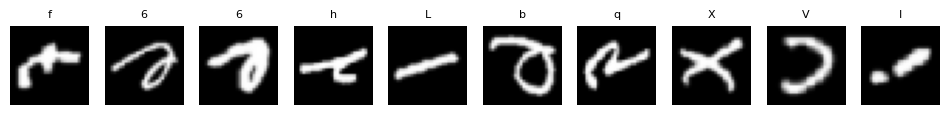

In [6]:
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]

    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        # Обратно денормализуем для отображения
        img = x[i].squeeze().numpy()
        img = img * 0.5 + 0.5
        plt.imshow(img, cmap="gray")
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=10)

In [7]:
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 47,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Быстрый sanity-check по форме
model = MLP(dropout_p=0.2, use_batchnorm=True).to(device)
with torch.no_grad():
    out = model(x_batch.to(device))
print("logits:", out.shape)

logits: torch.Size([256, 47])


In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # включаем train-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()  # включаем eval-режим (Dropout/BatchNorm!)
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [9]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        # score: чем больше, тем лучше (например, val_acc).
        # Возвращает True, если нужно остановиться.
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


In [10]:
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

epoch 01/20 | train loss=1.4198, acc=0.6033 | val loss=0.9646, acc=0.7104
epoch 02/20 | train loss=0.8015, acc=0.7561 | val loss=0.7261, acc=0.7751
epoch 03/20 | train loss=0.6398, acc=0.7974 | val loss=0.6155, acc=0.8133
epoch 04/20 | train loss=0.5629, acc=0.8169 | val loss=0.5724, acc=0.8154
epoch 05/20 | train loss=0.5150, acc=0.8294 | val loss=0.5357, acc=0.8288
epoch 06/20 | train loss=0.4809, acc=0.8380 | val loss=0.5436, acc=0.8269
epoch 07/20 | train loss=0.4536, acc=0.8445 | val loss=0.5274, acc=0.8291
epoch 08/20 | train loss=0.4331, acc=0.8507 | val loss=0.5043, acc=0.8368
epoch 09/20 | train loss=0.4131, acc=0.8543 | val loss=0.4898, acc=0.8405
epoch 10/20 | train loss=0.3952, acc=0.8614 | val loss=0.5044, acc=0.8363
epoch 11/20 | train loss=0.3800, acc=0.8651 | val loss=0.4856, acc=0.8451
epoch 12/20 | train loss=0.3683, acc=0.8688 | val loss=0.5053, acc=0.8350
epoch 13/20 | train loss=0.3563, acc=0.8708 | val loss=0.5020, acc=0.8345
epoch 14/20 | train loss=0.3453, acc=0

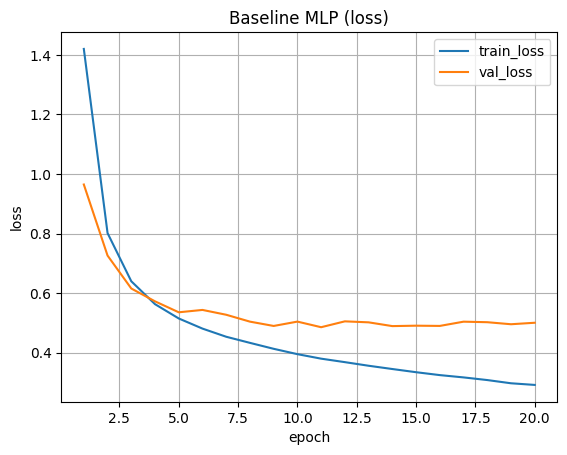

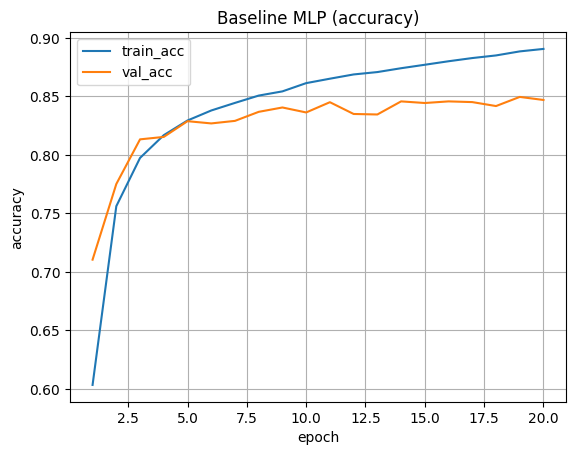

In [11]:
# Baseline: без Dropout и BatchNorm
set_seed(42)
baseline = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=1e-3)

history_baseline = fit(
    baseline, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_baseline, title="Baseline MLP")

In [12]:
# Финальная проверка на test
test_loss, test_acc = evaluate(baseline, test_loader, criterion, device)
print(f"Baseline test: loss={test_loss:.4f}, acc={test_acc:.4f}")

Baseline test: loss=0.5350, acc=0.8383


## Эксперимент 1: Dropout

Dropout случайно зануляет часть нейронов на обучении.
Эффект:
- модель хуже запоминает шум или частности,
- часто лучше обобщает на validation.

Важно: Dropout активен только в `model.train()`; в `model.eval()` он выключен.

epoch 01/20 | train loss=1.7659, acc=0.4992 | val loss=0.9664, acc=0.7123
epoch 02/20 | train loss=1.0988, acc=0.6672 | val loss=0.7686, acc=0.7693
epoch 03/20 | train loss=0.9467, acc=0.7073 | val loss=0.6781, acc=0.7928
epoch 04/20 | train loss=0.8692, acc=0.7290 | val loss=0.6531, acc=0.7951
epoch 05/20 | train loss=0.8218, acc=0.7413 | val loss=0.5946, acc=0.8104
epoch 06/20 | train loss=0.7893, acc=0.7490 | val loss=0.5800, acc=0.8134
epoch 07/20 | train loss=0.7693, acc=0.7542 | val loss=0.5574, acc=0.8239
epoch 08/20 | train loss=0.7457, acc=0.7601 | val loss=0.5501, acc=0.8236
epoch 09/20 | train loss=0.7295, acc=0.7636 | val loss=0.5378, acc=0.8283
epoch 10/20 | train loss=0.7134, acc=0.7689 | val loss=0.5301, acc=0.8286
epoch 11/20 | train loss=0.7014, acc=0.7708 | val loss=0.5268, acc=0.8294
epoch 12/20 | train loss=0.6959, acc=0.7731 | val loss=0.5087, acc=0.8358
epoch 13/20 | train loss=0.6817, acc=0.7768 | val loss=0.5125, acc=0.8373
epoch 14/20 | train loss=0.6776, acc=0

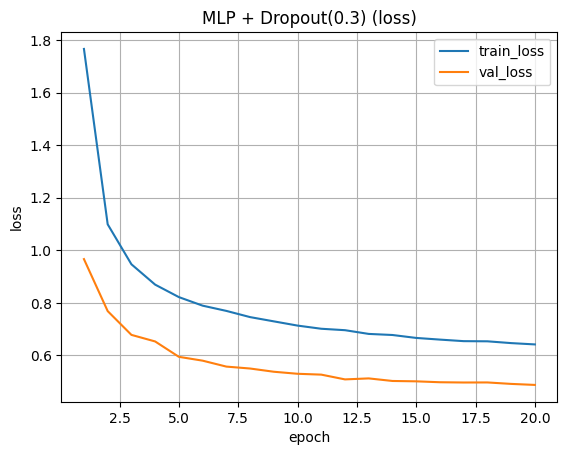

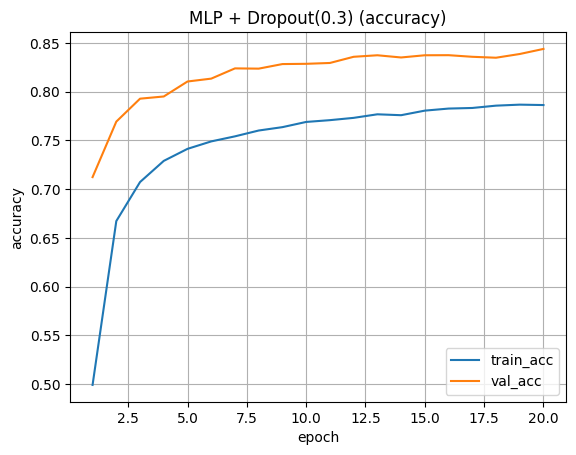

Dropout test: loss=0.5022, acc=0.8340


In [13]:
set_seed(42)
dropout_model = MLP(hidden_dims=(256, 128), dropout_p=0.3, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(dropout_model.parameters(), lr=1e-3)

history_dropout = fit(
    dropout_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_dropout, title="MLP + Dropout(0.3)")
test_loss, test_acc = evaluate(dropout_model, test_loader, criterion, device)
print(f"Dropout test: loss={test_loss:.4f}, acc={test_acc:.4f}")

## Эксперимент 2: BatchNorm

BatchNorm нормализует активации внутри сети.
Обычно даёт:
- более стабильное обучение,
- иногда выше итоговое качество,
- меньшую чувствительность к инициализации и масштабам.

Важно: BatchNorm использует разные статистики в train/eval режиме, поэтому переключение режимов критично.

epoch 01/20 | train loss=1.0892, acc=0.7207 | val loss=0.6321, acc=0.8032
epoch 02/20 | train loss=0.5321, acc=0.8276 | val loss=0.5313, acc=0.8236
epoch 03/20 | train loss=0.4434, acc=0.8498 | val loss=0.4872, acc=0.8382
epoch 04/20 | train loss=0.3934, acc=0.8645 | val loss=0.4654, acc=0.8459
epoch 05/20 | train loss=0.3618, acc=0.8717 | val loss=0.4815, acc=0.8393
epoch 06/20 | train loss=0.3343, acc=0.8807 | val loss=0.4584, acc=0.8458
epoch 07/20 | train loss=0.3136, acc=0.8861 | val loss=0.4656, acc=0.8445
epoch 08/20 | train loss=0.2965, acc=0.8902 | val loss=0.4572, acc=0.8460
epoch 09/20 | train loss=0.2785, acc=0.8961 | val loss=0.4577, acc=0.8500
epoch 10/20 | train loss=0.2686, acc=0.8977 | val loss=0.4590, acc=0.8508
epoch 11/20 | train loss=0.2538, acc=0.9033 | val loss=0.4769, acc=0.8484
epoch 12/20 | train loss=0.2429, acc=0.9066 | val loss=0.4836, acc=0.8456
epoch 13/20 | train loss=0.2315, acc=0.9097 | val loss=0.4967, acc=0.8452
epoch 14/20 | train loss=0.2222, acc=0

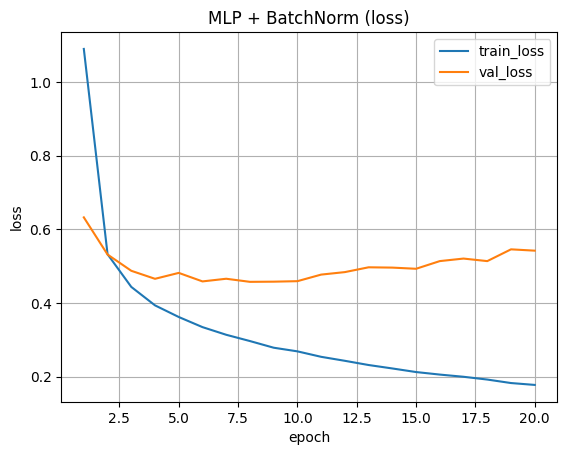

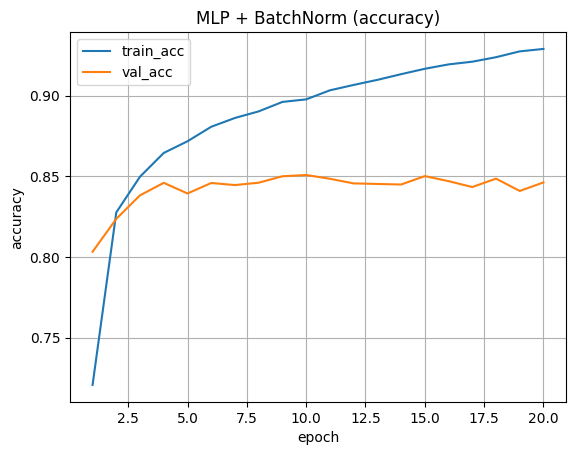

BatchNorm test: loss=0.5535, acc=0.8440


In [14]:
set_seed(42)
bn_model = MLP(num_classes=len(class_names), hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(bn_model.parameters(), lr=1e-3)

history_bn = fit(
    bn_model, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_bn, title="MLP + BatchNorm")
test_loss, test_acc = evaluate(bn_model, test_loader, criterion, device)
print(f"BatchNorm test: loss={test_loss:.4f}, acc={test_acc:.4f}")

## Эксперимент 3: Dropout, BatchNorm, EarlyStopping

Теперь соберём практичный вариант:
- Dropout с BatchNorm,
- и добавим EarlyStopping по val accuracy.

Идея: не тратить эпохи впустую и не уехать в переобучение.


--- Выбор для E4 ---
E2 (Dropout) final val_accuracy: 0.8438
E3 (BatchNorm) final val_accuracy: 0.8462
Выбрана архитектура E3 (BatchNorm) для эксперимента E4.

--- Запуск E4 (на основе E3) с EarlyStopping ---
epoch 01/50 | train loss=1.0892, acc=0.7207 | val loss=0.6321, acc=0.8032
epoch 02/50 | train loss=0.5321, acc=0.8276 | val loss=0.5313, acc=0.8236
epoch 03/50 | train loss=0.4434, acc=0.8498 | val loss=0.4872, acc=0.8382
epoch 04/50 | train loss=0.3934, acc=0.8645 | val loss=0.4654, acc=0.8459
epoch 05/50 | train loss=0.3618, acc=0.8717 | val loss=0.4815, acc=0.8393
epoch 06/50 | train loss=0.3343, acc=0.8807 | val loss=0.4584, acc=0.8458
epoch 07/50 | train loss=0.3136, acc=0.8861 | val loss=0.4656, acc=0.8445
epoch 08/50 | train loss=0.2965, acc=0.8902 | val loss=0.4572, acc=0.8460
EarlyStopping: остановка на эпохе 8. Лучший val_acc=0.8459


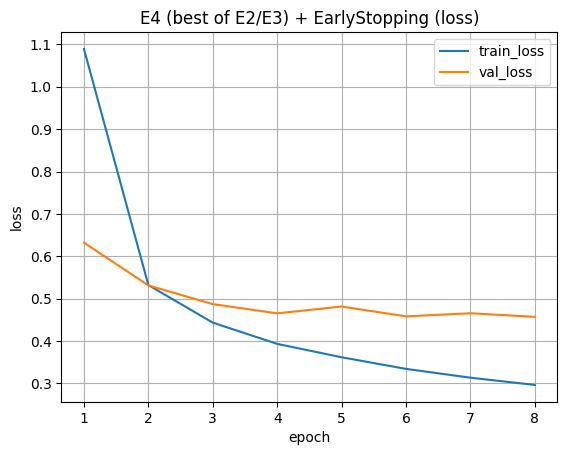

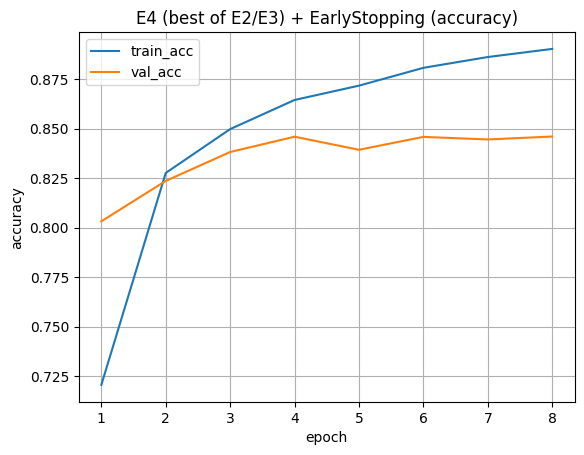


--- Финальная оценка E4 на test ---
E4 Best Model Test: loss=0.4837, acc=0.8415


In [15]:
# Эксперимент 3: Dropout, BatchNorm, EarlyStopping
# 1. Получаем финальные val_accuracy для E2 и E3
val_acc_e2 = history_dropout["val_acc"][-1]
val_acc_e3 = history_bn["val_acc"][-1]

print(f"\n--- Выбор для E4 ---")
print(f"E2 (Dropout) final val_accuracy: {val_acc_e2:.4f}")
print(f"E3 (BatchNorm) final val_accuracy: {val_acc_e3:.4f}")

# 2. Программно выбираем лучшую конфигурацию
if val_acc_e2 > val_acc_e3:
    print("Выбрана архитектура E2 (Dropout) для эксперимента E4.")
    e4_dropout_p = 0.3
    e4_use_batchnorm = False
    e4_base_experiment = "E2"
else:
    print("Выбрана архитектура E3 (BatchNorm) для эксперимента E4.")
    e4_dropout_p = 0.0
    e4_use_batchnorm = True
    e4_base_experiment = "E3"

# 3. Обучаем лучшую модель с EarlyStopping
set_seed(42)
e4_model = MLP(
    num_classes=len(class_names),
    hidden_dims=(256, 128),
    dropout_p=e4_dropout_p,
    use_batchnorm=e4_use_batchnorm
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer_e4 = optim.Adam(e4_model.parameters(), lr=1e-3)

es = EarlyStopping(patience=4, min_delta=0.0005)

print(f"\n--- Запуск E4 (на основе {e4_base_experiment}) с EarlyStopping ---")
history_e4 = fit(
    e4_model, train_loader, val_loader,
    optimizer_e4, criterion, device,
    epochs=50,  # Даем больше эпох, т.к. есть ранняя остановка
    early_stopping=es,
    verbose=True
)

plot_history(history_e4, title=f"E4 (best of E2/E3) + EarlyStopping")

# 4. Финальная оценка лучшей модели (E4) на тестовом наборе
print("\n--- Финальная оценка E4 на test ---")
test_loss_e4, test_acc_e4 = evaluate(e4_model, test_loader, criterion, device)
print(f"E4 Best Model Test: loss={test_loss_e4:.4f}, acc={test_acc_e4:.4f}")

## Часть B (S09): LR, оптимизаторы, weight decay (обязательно)


--- Запуск O1 (LR слишком большой) ---
epoch 01/8 | train loss=1.0052, acc=0.6938 | val loss=0.7996, acc=0.7511
epoch 02/8 | train loss=0.6816, acc=0.7793 | val loss=0.6716, acc=0.7793
epoch 03/8 | train loss=0.6080, acc=0.7980 | val loss=0.6345, acc=0.7970
epoch 04/8 | train loss=0.5720, acc=0.8075 | val loss=0.6084, acc=0.8043
epoch 05/8 | train loss=0.5438, acc=0.8161 | val loss=0.6583, acc=0.7941
epoch 06/8 | train loss=0.5254, acc=0.8206 | val loss=0.6074, acc=0.8135
epoch 07/8 | train loss=0.5050, acc=0.8270 | val loss=0.5769, acc=0.8176
epoch 08/8 | train loss=0.5016, acc=0.8281 | val loss=0.5712, acc=0.8186


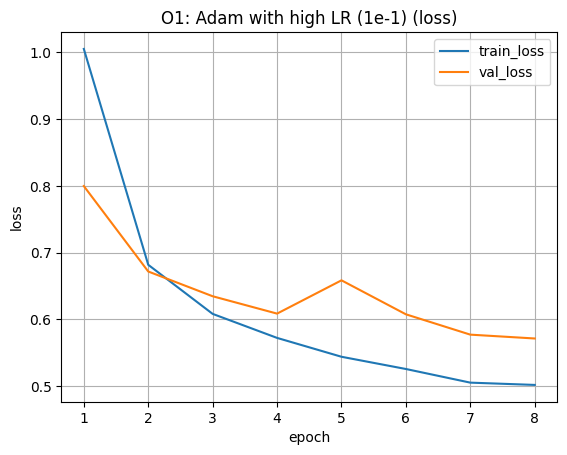

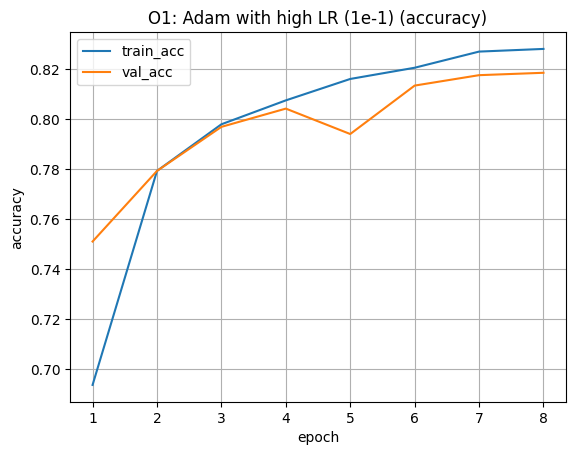


--- Запуск O2 (LR слишком маленький) ---
epoch 01/8 | train loss=3.5897, acc=0.1204 | val loss=3.2960, acc=0.2350
epoch 02/8 | train loss=3.1011, acc=0.3257 | val loss=2.9296, acc=0.3988
epoch 03/8 | train loss=2.8038, acc=0.4450 | val loss=2.6853, acc=0.4839
epoch 04/8 | train loss=2.5855, acc=0.5118 | val loss=2.4952, acc=0.5317
epoch 05/8 | train loss=2.4079, acc=0.5558 | val loss=2.3292, acc=0.5713
epoch 06/8 | train loss=2.2543, acc=0.5867 | val loss=2.1899, acc=0.5979
epoch 07/8 | train loss=2.1185, acc=0.6096 | val loss=2.0625, acc=0.6214
epoch 08/8 | train loss=1.9962, acc=0.6292 | val loss=1.9429, acc=0.6355


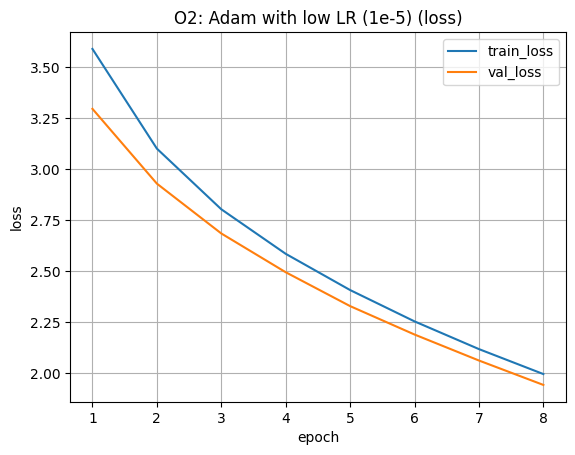

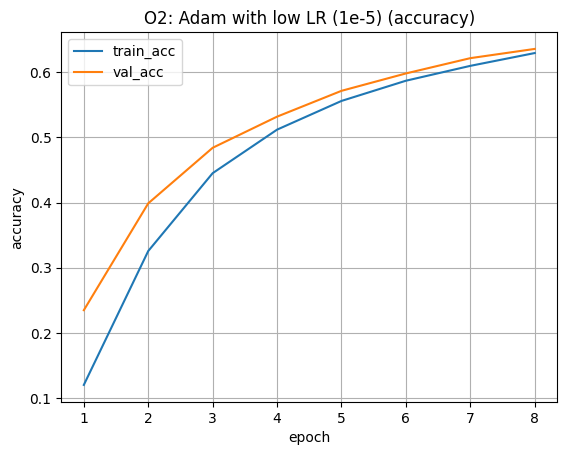


--- Запуск O3 (SGD + momentum + weight_decay) ---
epoch 01/15 | train loss=1.3469, acc=0.6655 | val loss=0.7303, acc=0.7879
epoch 02/15 | train loss=0.6251, acc=0.8069 | val loss=0.5798, acc=0.8185
epoch 03/15 | train loss=0.5121, acc=0.8347 | val loss=0.5177, acc=0.8359
epoch 04/15 | train loss=0.4543, acc=0.8490 | val loss=0.5006, acc=0.8393
epoch 05/15 | train loss=0.4171, acc=0.8591 | val loss=0.4927, acc=0.8388
epoch 06/15 | train loss=0.3875, acc=0.8676 | val loss=0.4699, acc=0.8453
epoch 07/15 | train loss=0.3665, acc=0.8733 | val loss=0.4701, acc=0.8429
epoch 08/15 | train loss=0.3473, acc=0.8788 | val loss=0.4597, acc=0.8467
epoch 09/15 | train loss=0.3305, acc=0.8822 | val loss=0.4613, acc=0.8454
epoch 10/15 | train loss=0.3174, acc=0.8875 | val loss=0.4523, acc=0.8521
epoch 11/15 | train loss=0.3047, acc=0.8917 | val loss=0.4625, acc=0.8506
epoch 12/15 | train loss=0.2946, acc=0.8941 | val loss=0.4560, acc=0.8510
epoch 13/15 | train loss=0.2828, acc=0.8972 | val loss=0.4666

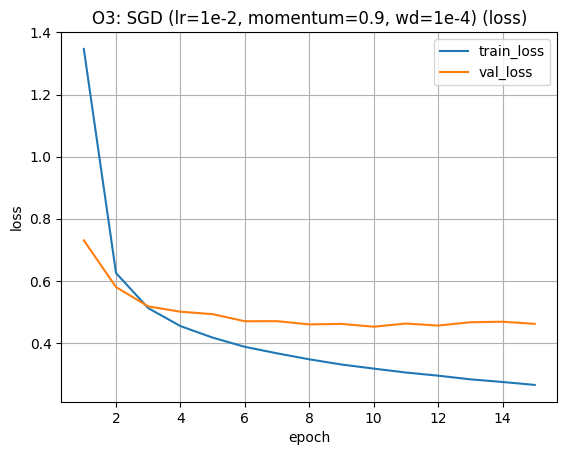

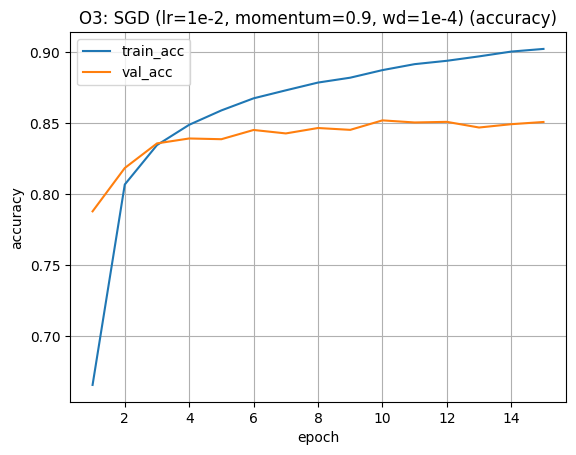

In [17]:
# Эксперименты O1, O2, O3 на архитектуре E4
e4_arch_config = {
    "num_classes": len(class_names),
    "hidden_dims": (256, 128),
    "dropout_p": e4_dropout_p,
    "use_batchnorm": e4_use_batchnorm
}

# O1: LR слишком большой
print("\n--- Запуск O1 (LR слишком большой) ---")
set_seed(42)
o1_model = MLP(**e4_arch_config).to(device)
optimizer_o1 = optim.Adam(o1_model.parameters(), lr=1e-1)
history_o1 = fit(o1_model, train_loader, val_loader, optimizer_o1, criterion, device, epochs=8, verbose=True)
plot_history(history_o1, title="O1: Adam with high LR (1e-1)")

# O2: LR слишком маленький
print("\n--- Запуск O2 (LR слишком маленький) ---")
set_seed(42)
o2_model = MLP(**e4_arch_config).to(device)
optimizer_o2 = optim.Adam(o2_model.parameters(), lr=1e-5)
history_o2 = fit(o2_model, train_loader, val_loader, optimizer_o2, criterion, device, epochs=8, verbose=True)
plot_history(history_o2, title="O2: Adam with low LR (1e-5)")

# O3: SGD с momentum и weight_decay
print("\n--- Запуск O3 (SGD + momentum + weight_decay) ---")
set_seed(42)
o3_model = MLP(**e4_arch_config).to(device)
optimizer_o3 = optim.SGD(o3_model.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4)
history_o3 = fit(o3_model, train_loader, val_loader, optimizer_o3, criterion, device, epochs=15, verbose=True)
plot_history(history_o3, title="O3: SGD (lr=1e-2, momentum=0.9, wd=1e-4)")

## 4. Артефакты (обязательно)

In [20]:
artifacts_dir = "artifacts"
figures_dir = os.path.join(artifacts_dir, "figures")
os.makedirs(figures_dir, exist_ok=True)

def get_run_data(exp_id, history, model_config, optimizer_config):
    return OrderedDict([
        ("experiment_id", exp_id),
        ("dataset", "EMNIST(split='balanced')"),
        ("seed", 42),
        ("model_summary", f"hidden:{model_config['hidden_dims']}, act:relu, dropout:{model_config['dropout_p']}, bn:{model_config['use_batchnorm']}"),
        ("optimizer", optimizer_config.get('name')),
        ("lr", optimizer_config.get('lr')),
        ("momentum", optimizer_config.get('momentum')),
        ("weight_decay", optimizer_config.get('weight_decay')),
        ("epochs_trained", len(history['val_acc'])),
        ("best_val_accuracy", max(history['val_acc']) if history['val_acc'] else None),
        ("best_val_loss", min(history['val_loss']) if history['val_loss'] else None)
    ])

all_runs_data = []
all_runs_data.append(get_run_data("E1", history_baseline, {'hidden_dims': (256, 128), 'dropout_p': 0.0, 'use_batchnorm': False}, {'name': 'Adam', 'lr': 1e-3, 'weight_decay': 0.0}))
all_runs_data.append(get_run_data("E2", history_dropout, {'hidden_dims': (256, 128), 'dropout_p': 0.3, 'use_batchnorm': False}, {'name': 'Adam', 'lr': 1e-3, 'weight_decay': 0.0}))
all_runs_data.append(get_run_data("E3", history_bn, {'hidden_dims': (256, 128), 'dropout_p': 0.0, 'use_batchnorm': True}, {'name': 'Adam', 'lr': 1e-3, 'weight_decay': 0.0}))
all_runs_data.append(get_run_data("E4", history_e4, e4_arch_config, {'name': 'Adam', 'lr': 1e-3, 'weight_decay': 0.0}))
all_runs_data.append(get_run_data("O1", history_o1, e4_arch_config, {'name': 'Adam', 'lr': 1e-1, 'weight_decay': 0.0}))
all_runs_data.append(get_run_data("O2", history_o2, e4_arch_config, {'name': 'Adam', 'lr': 1e-5, 'weight_decay': 0.0}))
all_runs_data.append(get_run_data("O3", history_o3, e4_arch_config, {'name': 'SGD', 'lr': 1e-2, 'momentum': 0.9, 'weight_decay': 1e-4}))

df_runs = pd.DataFrame(all_runs_data)
runs_csv_path = os.path.join(artifacts_dir, "runs.csv")
df_runs.to_csv(runs_csv_path, index=False)
print(f"Saved runs summary to {runs_csv_path}")

best_model_path = os.path.join(artifacts_dir, "best_model.pt")
torch.save(e4_model.state_dict(), best_model_path)
print(f"Saved best model (E4) to {best_model_path}")

best_config = {
    "architecture": e4_arch_config,
    "optimizer": {"name": "Adam", "lr": 1e-3, "weight_decay": 0.0},
    "training": {"epochs_trained": len(history_e4['val_acc']), "early_stopping_patience": es.patience, "batch_size": BATCH_SIZE},
    "seed": 42,
    "dataset": "EMNIST(split='balanced')"
}
best_config_path = os.path.join(artifacts_dir, "best_config.json")
with open(best_config_path, 'w') as f:
    json.dump(best_config, f, indent=4)
print(f"Saved best config to {best_config_path}")

# Generate and save figures
def save_plot(history, title, file_path):
    plt.figure()
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.savefig(file_path)
    plt.close()

curves_best_path = os.path.join(figures_dir, "curves_best.png")
save_plot(history_e4, "E4 (best model) Learning Curves", curves_best_path)
print(f"Saved best model curves to {curves_best_path}")

plt.figure()
epochs_o1 = np.arange(1, len(history_o1["val_loss"]) + 1)
plt.plot(epochs_o1, history_o1["val_loss"], label="O1: High LR (1e-1)")
epochs_o2 = np.arange(1, len(history_o2["val_loss"]) + 1)
plt.plot(epochs_o2, history_o2["val_loss"], label="O2: Low LR (1e-5)")
plt.xlabel("epoch")
plt.ylabel("validation loss")
plt.title("O1 vs O2: Extreme Learning Rates")
plt.legend()
plt.grid(True)
curves_lr_path = os.path.join(figures_dir, "curves_lr_extremes.png")
plt.savefig(curves_lr_path)
plt.close()
print(f"Saved LR curves to {curves_lr_path}")

Saved runs summary to artifacts/runs.csv
Saved best model (E4) to artifacts/best_model.pt
Saved best config to artifacts/best_config.json
Saved best model curves to artifacts/figures/curves_best.png
Saved LR curves to artifacts/figures/curves_lr_extremes.png
